In [16]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Display images inside notebook
%matplotlib inline

In [17]:
PROJECT_ROOT = Path("..")

print("Project Root:", PROJECT_ROOT.resolve())

TRAIN_PATH = PROJECT_ROOT / "dataset" / "raw" / "asl_alphabet_train"

print("Train Path:", TRAIN_PATH.resolve())
print("Exists:", TRAIN_PATH.exists())

Project Root: D:\Code FIles\VS code files\Project\sign-language-translator
Train Path: D:\Code FIles\VS code files\Project\sign-language-translator\dataset\raw\asl_alphabet_train
Exists: True


In [18]:
classes = sorted(
    [folder.name for folder in TRAIN_PATH.iterdir() if folder.is_dir()]
)

print(len(classes))
print(classes)

29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [19]:
image_counts = {}

for class_name in classes:
    folder = TRAIN_PATH / class_name
    image_counts[class_name] = len(list(folder.glob("*")))

df = pd.DataFrame(
    image_counts.items(),
    columns=["Class", "Images"]
)

df

,Class,Images
0,A,3000
1,B,3000
2,C,3000
3,D,3000
4,E,3000
5,F,3000
6,G,3000
7,H,3000
8,I,3000
9,J,3000


In [20]:
import os

for item in sorted(os.listdir(TRAIN_PATH)):
    print(item)

A
B
C
D
E
F
G
H
I
J
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y
Z
del
nothing
space


In [22]:
print("Total Classes :", len(df))
print("Total Images :", df["Images"].sum())

Total Classes : 29
Total Images : 87000


In [25]:
print("ASL DATASET SUMMARY")

print(f"Number of Classes      : {len(df)}")
print(f"Total Images           : {df['Images'].sum():,}")
print(f"Average Images/Class   : {df['Images'].mean():.2f}")
print(f"Minimum Images/Class   : {df['Images'].min()}")
print(f"Maximum Images/Class   : {df['Images'].max()}")

ASL DATASET SUMMARY
Number of Classes      : 29
Total Images           : 87,000
Average Images/Class   : 3000.00
Minimum Images/Class   : 3000
Maximum Images/Class   : 3000


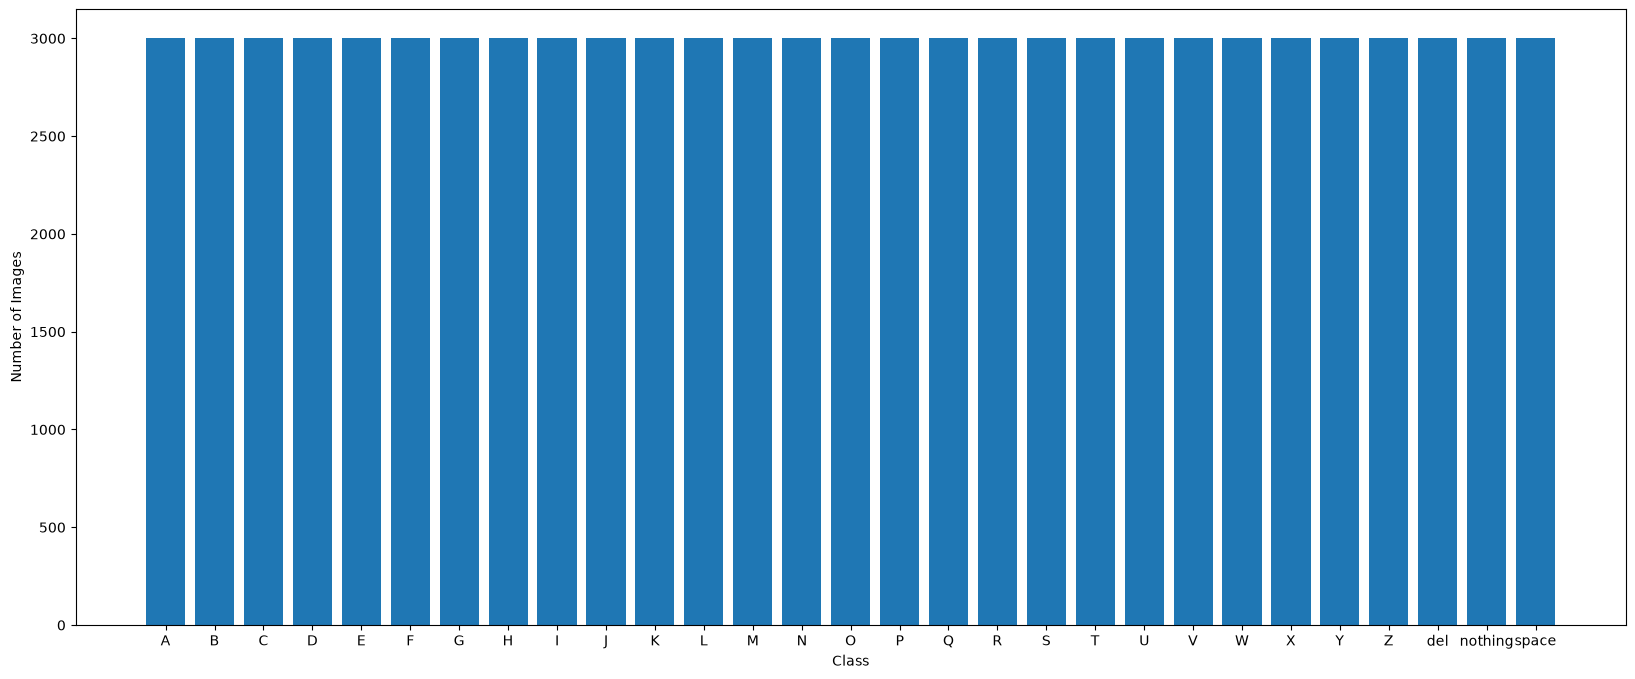

In [35]:
plt.figure(figsize=(20,8))

plt.bar(df["Class"], df["Images"])

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.show()

### Observation

The dataset is balanced.

Every class contains approximately 3000 images.

Balanced datasets reduce bias during model training.

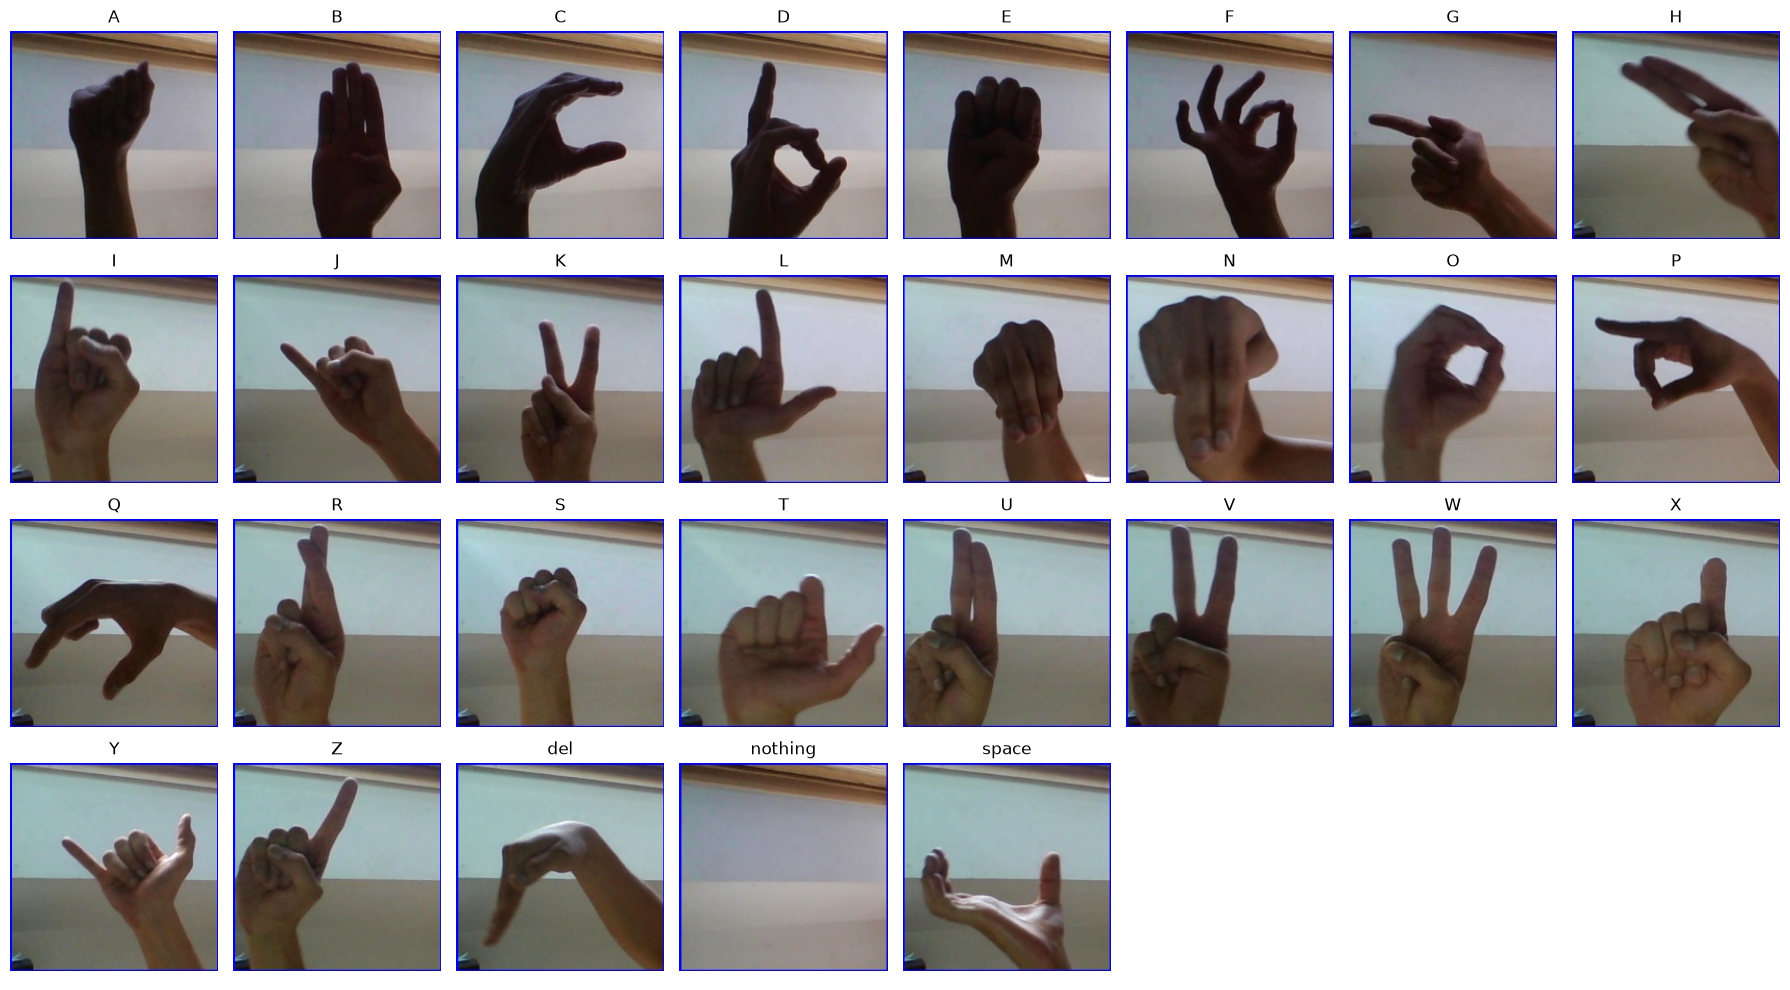

In [41]:
fig, axes = plt.subplots(4, 8, figsize=(18,10))

axes = axes.flatten()

for i, class_name in enumerate(classes):

    image_path = next((TRAIN_PATH / class_name).glob("*"))

    image = Image.open(image_path)

    axes[i].imshow(image)

    axes[i].set_title(class_name)

    axes[i].axis("off")

# Hide unused subplot (32 total - 29 images = 3 empty)
for j in range(len(classes), len(axes)):
    axes[j].axis("off")

plt.tight_layout()

plt.show()

In [42]:
sample = Image.open(next((TRAIN_PATH / classes[0]).glob("*")))

print("Image Size :", sample.size)

print("Image Mode :", sample.mode)

Image Size : (200, 200)
Image Mode : RGB


In [43]:
sizes = []

for class_name in classes:

    image_path = next((TRAIN_PATH / class_name).glob("*"))

    image = Image.open(image_path)

    sizes.append(image.size)

pd.Series(sizes).value_counts()

(200, 200)    29
Name: count, dtype: int64

In [44]:
corrupted = []

for class_name in classes:

    folder = TRAIN_PATH / class_name

    for image_path in folder.glob("*"):

        try:

            Image.open(image_path).verify()

        except Exception:

            corrupted.append(image_path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


In [45]:
import os

total_size = 0

for root, dirs, files in os.walk(TRAIN_PATH):

    for file in files:

        total_size += os.path.getsize(os.path.join(root, file))

print(f"Dataset Size : {total_size / (1024**3):.2f} GB")

Dataset Size : 1.03 GB


# EDA Summary

## Dataset Information

- Dataset Name: ASL Alphabet
- Number of Classes: 29
- Total Images: 87,000
- Images per Class: 3000
- Image Resolution: 200 × 200
- Image Channels: RGB

## Observations

- Dataset is balanced.
- Images have a black background.
- Hand occupies the central region.
- Image quality is consistent.
- No corrupted images found.
- Suitable for landmark extraction using MediaPipe.

## Next Step

Extract 21 hand landmarks using MediaPipe and convert each image into a numerical feature vector.